## Importando as Bibliotecas

In [32]:
# Manipulação e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Modelos estatísticos
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Métricas
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Validação e tuning
from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV
)

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from lightgbm import LGBMRegressor

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


# 1. Leitura e Validação dos Dados

In [33]:
# Leitura, transformação em datetime e modificando o index
dados = pd.read_csv("../data/dados_tratados.csv")
dados["data_hora"] = pd.to_datetime(dados["data_hora"], format="%Y-%m-%d %H:%M:%S")
dados = dados.set_index("data_hora")
dados = dados.drop(columns=["consumo_zona_2", "consumo_zona_3"])
dados.head()

,temperatura,umidade,velocidade_vento,fluxo_difuso_geral,fluxo_difuso,consumo_zona_1
data_hora,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620


In [34]:
print(f"Classe do Index -> {type(dados.index)}")
print(f"Shape -> {dados.shape}")

print(f"\nValores Ausentes -> {dados.isna().sum().sum()}")

print(f"\nOrdenado -> {dados.index.is_monotonic_increasing}")
print(f"\nFrequência -> {pd.infer_freq(dados.index)}")

print(f"\nPeríodo -> {dados.index.min().date()} até {dados.index.max().date()}")

Classe do Index -> <class 'pandas.DatetimeIndex'>
Shape -> (52416, 6)

Valores Ausentes -> 0

Ordenado -> True

Frequência -> 10min

Período -> 2017-01-01 até 2017-12-30


# 2. Divisão dos Dados de Modelagem e Teste Final

In [35]:
um_mes = 4320

dados_modelagem = dados.iloc[:-um_mes].copy()
teste_final = dados.iloc[-um_mes:].copy()

Dados Modelagem -> 2017-01-01 até 2017-11-30
Teste Final -> 2017-12-01 até 2017-12-30


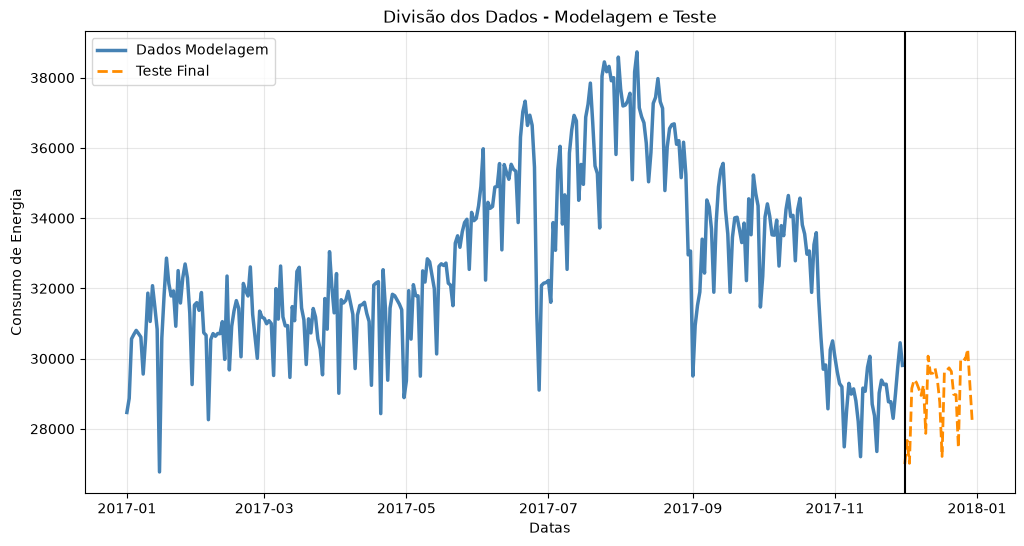

In [36]:
print(f"Dados Modelagem -> {dados_modelagem.index.min().date()} até {dados_modelagem.index.max().date()}")
print(f"Teste Final -> {teste_final.index.min().date()} até {teste_final.index.max().date()}")

modelagem_diaria = dados_modelagem["consumo_zona_1"].resample("D").mean()
teste_diaria = teste_final["consumo_zona_1"].resample("D").mean()

plt.figure(figsize=(12,6))

plt.plot(modelagem_diaria.index, modelagem_diaria, color="steelblue", linewidth=2.5, label="Dados Modelagem")
plt.plot(teste_diaria.index, teste_diaria, color="darkorange", linewidth=2.0 ,linestyle='--', label="Teste Final")
plt.axvline(teste_diaria.index[0], color='black', linewidth=1.5)
plt.title("Divisão dos Dados - Modelagem e Teste")
plt.xlabel("Datas")
plt.ylabel("Consumo de Energia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. Definição das Métricas

In [37]:
def calcula_metricas(y_real, previsto):
    mae = mean_absolute_error(y_real, previsto)
    rmse = np.sqrt(mean_squared_error(y_real, previsto))
    mape = mean_absolute_percentage_error(y_real, previsto)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

# 4. Modelos Estatísticos

## 4.1 Holt-Winters

In [38]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=4320
)

resultados_hw = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(dados_modelagem), start=1):

    treino = dados_modelagem.iloc[train_idx]["consumo_zona_1"]
    validacao = dados_modelagem.iloc[val_idx]["consumo_zona_1"]

    modelo = ExponentialSmoothing(
        treino,
        trend='add',
        seasonal='add',
        seasonal_periods=144
    ).fit()

    previsoes = modelo.forecast(steps=len(validacao))

    metricas = calcula_metricas(validacao, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "Holt-Winters"

    resultados_hw.append(metricas)

c:\Users\treve\OneDrive\Documentos\Renan Projetos\energy-demand-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
c:\Users\treve\OneDrive\Documentos\Renan Projetos\energy-demand-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
c:\Users\treve\OneDrive\Documentos\Renan Projetos\energy-demand-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
c:\Users\treve\OneDrive\Documentos\Renan Projetos\energy-demand-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferre

# 5. Modelos de Machine Learning

## 5.1 - Preparação dos Dados para Machine Learning

In [39]:
dados_ml = dados.copy()
target = "consumo_zona_1"

# Lags
dados_ml["lag_1"] = dados_ml[target].shift(1) # 10 min
dados_ml["lag_6"] = dados_ml[target].shift(6) # 1 hora
dados_ml["lag_144"] = dados_ml[target].shift(144) # 1 dia
dados_ml["lag_1008"] = dados_ml[target].shift(1008) # 1 semana

# Médias Móveis
dados_ml["rolling_mean_6"] = dados_ml[target].shift(1).rolling(6).mean()
dados_ml["rolling_mean_144"] = dados_ml[target].shift(1).rolling(144).mean()

# Variáveis Temporais
dados_ml["hora"] = dados_ml.index.hour
dados_ml["dia_da_semana"] = dados_ml.index.dayofweek

# Representação cíclica da hora
dados_ml["hora_sin"] = np.sin(2 * np.pi * dados_ml["hora"] / 24)

dados_ml["hora_cos"] = np.cos(2 * np.pi * dados_ml["hora"] / 24)

# Removendo columa de hora
dados_ml.drop(columns=["hora"], inplace=True)

# Removendo valores nulos
dados_ml = dados_ml.dropna()

In [40]:
dados_ml.head()

,temperatura,umidade,velocidade_vento,fluxo_difuso_geral,fluxo_difuso,consumo_zona_1,lag_1,lag_6,lag_144,lag_1008,rolling_mean_6,rolling_mean_144,dia_da_semana,hora_sin,hora_cos
data_hora,,,,,,,,,,,,,,,
2017-01-08 00:00:00,14.07,78.2,0.081,0.048,0.130,28332.15190,29401.51899,33812.65823,28927.59494,34055.69620,31526.075950,30612.700422,6,0.0,1.0
2017-01-08 00:10:00,14.19,77.8,0.085,0.044,0.111,27791.39241,28332.15190,32955.94937,28052.65823,29814.68354,30612.658228,30608.565401,6,0.0,1.0
2017-01-08 00:20:00,14.27,77.7,0.087,0.033,0.122,26831.39241,27791.39241,31868.35443,27220.25316,29128.10127,29751.898735,30606.751055,6,0.0,1.0
2017-01-08 00:30:00,14.34,77.7,0.092,0.055,0.134,26296.70886,26831.39241,30914.43038,26831.39241,28228.86076,28912.405065,30604.050633,6,0.0,1.0
2017-01-08 00:40:00,14.37,77.9,0.089,0.040,0.137,25585.82278,26296.70886,30203.54430,26363.54430,27335.69620,28142.784812,30600.337552,6,0.0,1.0


## 5.2 - Preparação dos Dados para Modelagem e Teste Final

In [41]:
data_inicio_teste = teste_final.index.min()
print(data_inicio_teste)

2017-12-01 00:00:00


In [42]:
dados_ml_modelagem = dados_ml.iloc[dados_ml.index < data_inicio_teste].copy()
teste_ml_final = dados_ml.iloc[dados_ml.index > data_inicio_teste].copy()

print(f"Dados ML Modelagem -> {dados_ml_modelagem.index.min().date()} até {dados_ml_modelagem.index.max().date()}")
print(f"Teste ML Final -> {teste_ml_final.index.min().date()} até {teste_ml_final.index.max().date()}")

Dados ML Modelagem -> 2017-01-08 até 2017-11-30
Teste ML Final -> 2017-12-01 até 2017-12-30


In [43]:
FEATURES = ['temperatura', 'umidade', 'velocidade_vento', 'fluxo_difuso_geral',
            'fluxo_difuso', 'lag_1', 'lag_6', 'lag_144', 'lag_1008', 'rolling_mean_6',
            'rolling_mean_144', 'dia_da_semana', 'hora_sin', 'hora_cos']

X_modelagem = dados_ml_modelagem[FEATURES]
y_modelagem = dados_ml_modelagem["consumo_zona_1"]

X_teste_final = teste_ml_final[FEATURES]
y_teste_final = teste_ml_final["consumo_zona_1"]

## 5.3 - Modelo Random Forest

In [44]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=4320
)

resultados_rf = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):

    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_treino, y_treino)

    pred = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, pred)

    metricas["Fold"] = fold
    metricas["Modelo"] = "Random Forest"

    resultados_rf.append(metricas)

## 5.4 - Modelo XGBoost

In [45]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=4320
)

resultados_xgb = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):
    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo_xgb = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.1,
        max_depth=5,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_treino, y_treino)

    pred = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, pred)

    metricas["Fold"] = fold
    metricas["Modelo"] = "XGBoost"

    resultados_xgb.append(metricas)

## 5.5 - Modelo LightGBM

In [46]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=4320
)

resultados_gbm = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):
    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.1,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    modelo.fit(X_treino, y_treino)

    pred = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, pred)

    metricas["Fold"] = fold
    metricas["Modelo"] = "LightGBM"

    resultados_gbm.append(metricas) 

# 6. Comparação Inicial dos Modelos

In [47]:
df_hw = pd.DataFrame(resultados_hw)
df_rf = pd.DataFrame(resultados_rf)
df_xgb = pd.DataFrame(resultados_xgb)
df_gbm = pd.DataFrame(resultados_gbm)

resultados = pd.concat([df_hw, df_rf, df_xgb, df_gbm])

comparacao = resultados.groupby("Modelo")[["MAE", "RMSE", "MAPE"]].agg(["mean", "std"]).round(3)
comparacao = comparacao.sort_values(by=("MAE", "mean"), ascending=True)
comparacao

MAE                    RMSE                MAPE        
                     mean         std        mean         std    mean     std
Modelo                                                                       
LightGBM          317.738      89.830     474.251     134.642   0.010   0.002
Random Forest     495.382      97.251     710.278     148.177   0.015   0.002
XGBoost           495.382      97.251     710.278     148.177   0.015   0.002
Holt-Winters   344768.376  327795.861  397935.269  378324.717  11.440  11.179

# 7. Otimiazação de Hiperparãmetros - RandomSearchCV

In [48]:
modelo_xgb = xgb.XGBRegressor(ojective="reg:absoluteerror", random_state=42, n_jobs=-1)

parametros_xgb = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [5, 7, 9],
    "min_child_weight": [1, 3, 5],
    "subsample": [ 0.9, 1.0],
    "colsample_bytree": [ 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 5, 10]
}

busca_xgb = RandomizedSearchCV(
    estimator=modelo_xgb,
    param_distributions=parametros_xgb,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

busca_xgb.fit(X_modelagem, y_modelagem)

print(f"Melhores Hiperparametros -> {busca_xgb.best_params_}")
print(f"Melhor Resultado MAE -> {-busca_xgb.best_score_}")

c:\Users\treve\OneDrive\Documentos\Renan Projetos\energy-demand-forecasting\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:15:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "ojective" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Melhores Hiperparametros -> {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Melhor Resultado MAE -> 294.95312335325525


In [49]:
modelo_gbm = LGBMRegressor(objective="regression", random_state=42, n_jobs=1, verbosity=-1)

parametros_lgbm = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [5, 7, 10],
    "min_child_samples": [10, 20, 30],
    "subsample": [0.9, 1.0],
    "colsample_bytree": [0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0, 1, 5, 10]
}

busca_gbm = RandomizedSearchCV(
    estimator=modelo_gbm,
    param_distributions=parametros_lgbm,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

busca_gbm.fit(X_modelagem, y_modelagem)

print(f"Melhores Hiperparâmetros -> {busca_gbm.best_params_}")
print(f"Melhor Resultado MAE -> {-busca_gbm.best_score_}")

Melhores Hiperparâmetros -> {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 1, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
Melhor Resultado MAE -> 296.2666129431808


# 8. Avaliação dos Modelos Otimizados

In [51]:
resultados_xgb_tuned = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):

    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = xgb.XGBRegressor(**busca_xgb.best_params_, objective="reg:squarederror", random_state=42, n_jobs=-1)

    modelo.fit(X_treino, y_treino)
    previsoes = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "XGBoost Tunnado"

    resultados_xgb_tuned.append(metricas)

In [52]:
resultados_gbm_tuned = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):

    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = LGBMRegressor(**busca_gbm.best_params_, objective="regression", random_state=42, n_jobs=1, verbosity=-1)

    modelo.fit(X_treino, y_treino)
    previsoes = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "LightGBM Tunnado"

    resultados_gbm_tuned.append(metricas)

## 8.1 - Comparação Final dos Modelos

In [53]:
df_xgb_tunado = pd.DataFrame(resultados_xgb_tuned)
df_gbm_tunado = pd.DataFrame(resultados_gbm_tuned)

resultados = pd.concat([resultados, df_xgb_tunado, df_gbm_tunado])

comparacao = resultados.groupby("Modelo")[["MAE", "RMSE", "MAPE"]].agg(["mean", "std"]).round(3)
comparacao = comparacao.sort_values(by=("MAE", "mean"), ascending=True)
comparacao

MAE                    RMSE                MAPE  \
                        mean         std        mean         std    mean   
Modelo                                                                     
XGBoost Tunnado      294.549      82.770     454.535     133.843   0.009   
LightGBM Tunnado     296.267      84.126     450.788     130.321   0.009   
LightGBM             317.738      89.830     474.251     134.642   0.010   
Random Forest        495.382      97.251     710.278     148.177   0.015   
XGBoost              495.382      97.251     710.278     148.177   0.015   
Holt-Winters      344768.376  327795.861  397935.269  378324.717  11.440   

                          
                     std  
Modelo                    
XGBoost Tunnado    0.002  
LightGBM Tunnado   0.002  
LightGBM           0.002  
Random Forest      0.002  
XGBoost            0.002  
Holt-Winters      11.179

In [58]:
comparacao = comparacao.drop(index="Holt-Winters")
comparacao

MAE             RMSE            MAPE       
                     mean     std     mean      std   mean    std
Modelo                                                           
XGBoost Tunnado   294.549  82.770  454.535  133.843  0.009  0.002
LightGBM Tunnado  296.267  84.126  450.788  130.321  0.009  0.002
LightGBM          317.738  89.830  474.251  134.642  0.010  0.002
Random Forest     495.382  97.251  710.278  148.177  0.015  0.002
XGBoost           495.382  97.251  710.278  148.177  0.015  0.002

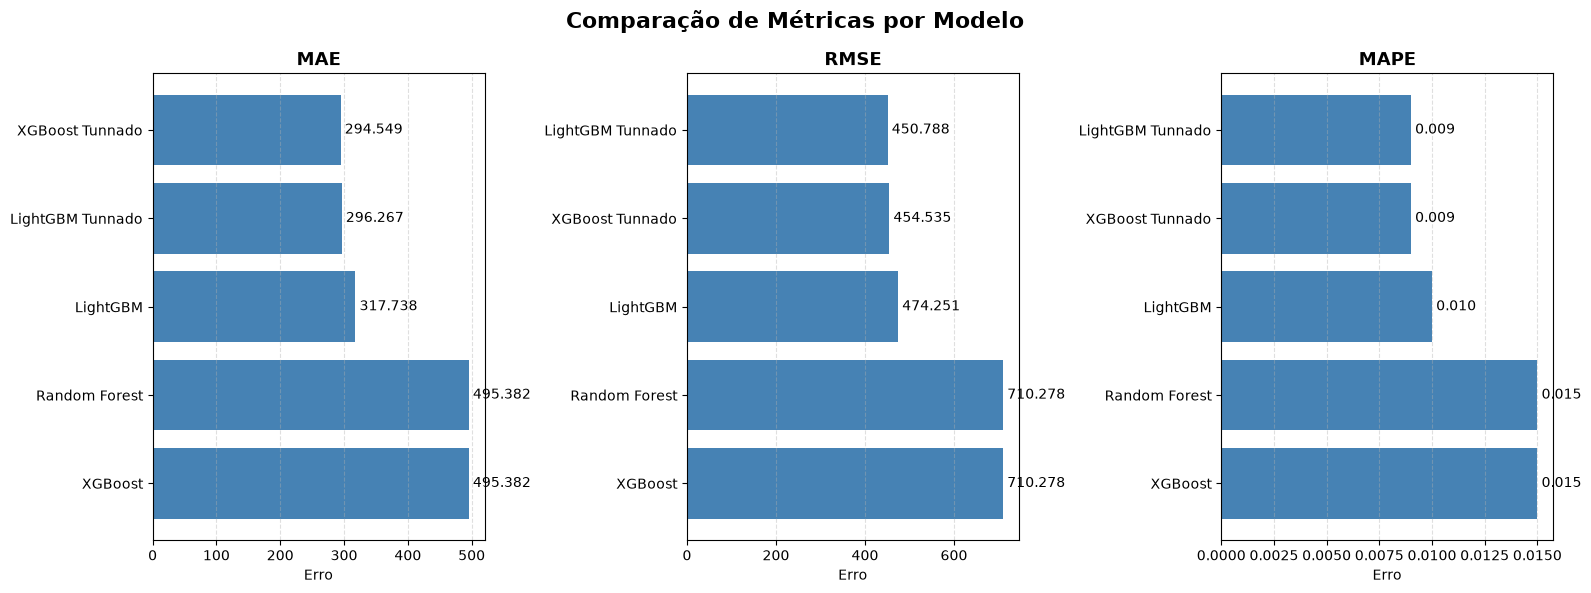

In [59]:
metricas_plot = pd.DataFrame({
    "MAE": comparacao[("MAE", "mean")],
    "RMSE": comparacao[("RMSE", "mean")],
    "MAPE": comparacao[("MAPE", "mean")]
})

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metricas = ["MAE", "RMSE", "MAPE"]

for ax, metrica in zip(axes, metricas):

    valores = metricas_plot[metrica].sort_values(ascending=False)

    bars = ax.barh(valores.index, valores.values, color="steelblue")

    ax.set_title(metrica, fontsize=13, fontweight="bold")

    ax.set_xlabel("Erro")

    ax.grid(axis="x", linestyle="--", alpha=0.4)

    ax.bar_label(bars, fmt="%.3f", padding=3)

fig.suptitle("Comparação de Métricas por Modelo", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()